In [9]:
from astropy.io import fits
import numpy as np
import matplotlib.pyplot as plt
import os
import subprocess

In [10]:
path_backgrounds = "lsb_optimized_jan25/"
path_backgrounds_without_pedestal_by_mask = "lsb_optimized_jan25_without_pedestal_by_mask/"

In [11]:
if not os.path.exists(path_backgrounds_without_pedestal_by_mask):
    os.makedirs(path_backgrounds_without_pedestal_by_mask)

In [12]:
path_background_vis = path_backgrounds + "EUC_VIS_LSB_ObsID_2706.fits"
path_background_nisp_y = path_backgrounds + "EUC_NIR_Y_LSB_ObsID_2706.fits"
path_background_nisp_j = path_backgrounds + "EUC_NIR_J_LSB_ObsID_2706.fits"
path_background_nisp_h = path_backgrounds + "EUC_NIR_H_LSB_ObsID_2706.fits"

In [13]:
path_background_vis_without_pedestal = path_backgrounds_without_pedestal_by_mask + "EUC_VIS_LSB_ObsID_2706.fits"
path_background_nisp_y_without_pedestal = path_backgrounds_without_pedestal_by_mask + "EUC_NIR_Y_LSB_ObsID_2706.fits"
path_background_nisp_j_without_pedestal = path_backgrounds_without_pedestal_by_mask + "EUC_NIR_J_LSB_ObsID_2706.fits"
path_background_nisp_h_without_pedestal = path_backgrounds_without_pedestal_by_mask + "EUC_NIR_H_LSB_ObsID_2706.fits"

In [14]:
def procesar_imagen(input_image, output_folder="./"):
    """
    Procesa una imagen FITS utilizando NoiseChisel y calcula el pedestal del cielo.
    
    Args:
        input_image: Ruta completa a la imagen FITS de entrada
        output_folder: Carpeta donde guardar los archivos de salida
    
    Returns:
        float: El valor del pedestal del cielo calculado
    """
    # Asegurarse de que la carpeta de salida exista
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
    
    # Extraer el nombre de la imagen sin extensión
    input_image_base = os.path.basename(input_image)
    input_image_no_extension = os.path.splitext(input_image_base)[0]
    
    # Definir nombre del archivo de salida de NoiseChisel
    noisechiseling_original = f"{input_image_no_extension}_noisechiseling_original.fits"
    output_noisechisel_image = os.path.join(output_folder, noisechiseling_original)
    
    # Ejecutar el comando NoiseChisel
    path_to_image = os.path.dirname(input_image) + "/" if os.path.dirname(input_image) else ""
    comando = f"astnoisechisel \"{path_to_image}{input_image_no_extension}.fits\" -h0 --output={output_noisechisel_image}"
    
    print(f"Ejecutando: {comando}")
    subprocess.run(comando, shell=True, check=True)
    
    # Procesar la imagen con la máscara
    # Cargar la imagen original
    img = fits.getdata(input_image)
    
    # Cargar la máscara de NoiseChisel (está en la extensión 2)
    hdu = fits.open(output_noisechisel_image)
    whole_mask = hdu[2].data.astype(float)  # Máscara que cubre toda la imagen
    hdr = hdu[2].header
    
    # Reemplazar los valores 0 con NaN
    whole_mask[whole_mask == 0] = float("NaN")
    
    # Aplicar la máscara a la imagen
    masked_image = img * whole_mask
    
    # Calcular el pedestal del cielo usando la mediana de los píxeles no enmascarados
    pedestal_sky = np.nanmedian(masked_image)
    
    print("\n")
    print(f"Pedestal del cielo: {pedestal_sky}")
    print("\n")
    
    return pedestal_sky

In [15]:
pedestal_sky_vis = procesar_imagen(path_background_vis)

Ejecutando: astnoisechisel "lsb_optimized_jan25/EUC_VIS_LSB_ObsID_2706.fits" -h0 --output=./EUC_VIS_LSB_ObsID_2706_noisechiseling_original.fits
NoiseChisel 0.22 started on Sun May 11 10:45:54 2025
  - Using 12 CPU threads.
  - Input: lsb_optimized_jan25/EUC_VIS_LSB_ObsID_2706.fits (hdu: 0)
  - Kernel: FWHM=2 pixel Gaussian.
  - Convolved with given kernel.                       78.216063 seconds
  - Starting to find initial detections.
  ---- 0.30 & 0.99 quantile thresholds applied.        194.385566 seconds
  ---- Eroded 2 times (4-connected).                   7.097938 seconds
  ---- Opened (depth: 1, 8-connected).                 5.040542 seconds
  - 4061331 initial detections found.                  222.352329 seconds
  - Starting to find/remove false detections.
  ---- Initial (crude) Sky and its STD found.          144.816038 seconds
  ---- Pseudo-detection thresh (0.000 sigma) applied.  1.164996 seconds
  ---- Pseudo-det S/N: 8.448 (0.99 quant of 3497713).  36.200334 seconds
  -

## VIS

-33.777027
179.94199
0.0230471
0.7239921


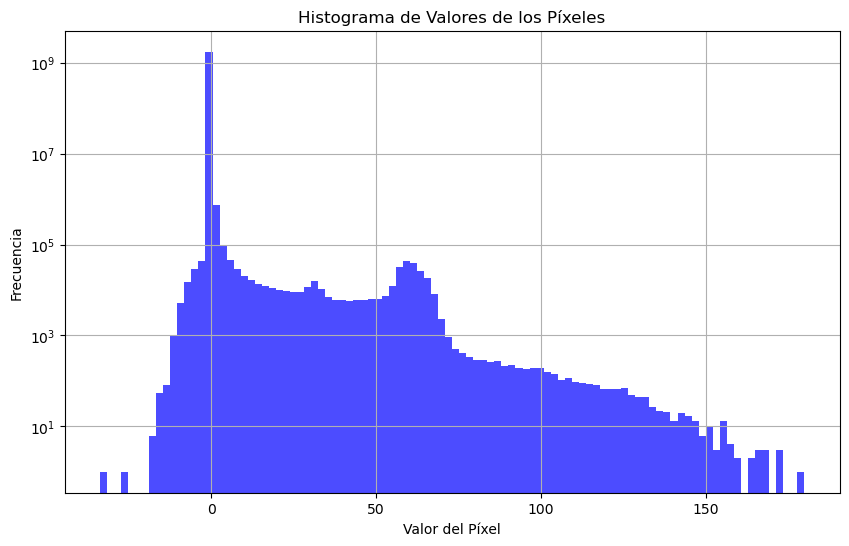

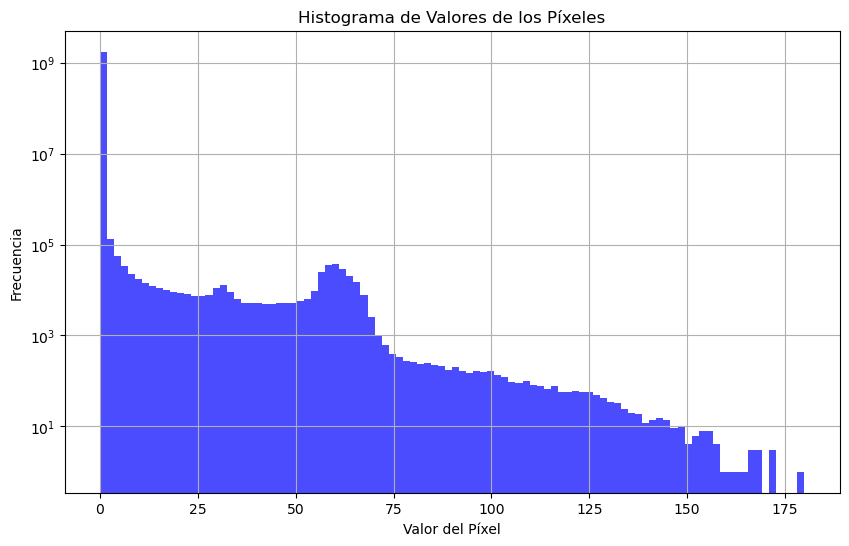

In [17]:
# Abrir el archivo FITS original
hdu_list = fits.open(path_background_vis)
image_data = hdu_list[0].data
header = hdu_list[0].header  # Copiar la cabecera
hdu_list.close()

# Calcular la media y la desviación estándar de toda la imagen
mean_background = np.nanmedian(image_data)
std_background = np.nanstd(image_data)
min_val = np.nanmin(image_data)
print(min_val)
max_val = np.nanmax(image_data)
print(max_val)

print(mean_background)
print(std_background)

# Mostrar el histograma de los valores de los píxeles
plt.figure(figsize=(10, 6))
plt.hist(image_data.flatten(), bins=100, color='blue', alpha=0.7)
plt.title('Histograma de Valores de los Píxeles')
plt.xlabel('Valor del Píxel')
plt.ylabel('Frecuencia')
plt.yscale('log')  # Usar escala logarítmica para mejor visualización
plt.grid(True)
plt.show()

# Sustraer el ruido de fondo de la imagen completa
image_data_subtracted = image_data - pedestal_sky_vis
# Ajustar los valores negativos a 0
image_data_subtracted = np.maximum(image_data_subtracted, 1e-10)
# Guardar la imagen con el ruido sustraído y la cabecera original
fits.writeto(path_background_vis_without_pedestal, image_data_subtracted, header=header, overwrite=True)

# Mostrar el histograma de los valores de los píxeles
plt.figure(figsize=(10, 6))
plt.hist(image_data_subtracted.flatten(), bins=100, color='blue', alpha=0.7)
plt.title('Histograma de Valores de los Píxeles')
plt.xlabel('Valor del Píxel')
plt.ylabel('Frecuencia')
plt.yscale('log')  # Usar escala logarítmica para mejor visualización
plt.grid(True)
plt.show()

## NISP H

In [18]:
pedestal_sky_nisp_h = procesar_imagen(path_background_nisp_h)

Ejecutando: astnoisechisel "lsb_optimized_jan25/EUC_NIR_H_LSB_ObsID_2706.fits" -h0 --output=./EUC_NIR_H_LSB_ObsID_2706_noisechiseling_original.fits
NoiseChisel 0.22 started on Sun May 11 11:11:11 2025
  - Using 12 CPU threads.
  - Input: lsb_optimized_jan25/EUC_NIR_H_LSB_ObsID_2706.fits (hdu: 0)
  - Kernel: FWHM=2 pixel Gaussian.
  - Convolved with given kernel.                       8.554426 seconds
  - Starting to find initial detections.
  ---- 0.30 & 0.99 quantile thresholds applied.        5.517598 seconds
  ---- Eroded 2 times (4-connected).                   0.720966 seconds
  ---- Opened (depth: 1, 8-connected).                 0.567481 seconds
  - 303111 initial detections found.                   9.161871 seconds
  - Starting to find/remove false detections.
  ---- Initial (crude) Sky and its STD found.          4.706620 seconds
  ---- Pseudo-detection thresh (0.000 sigma) applied.  0.110968 seconds
  ---- Pseudo-det S/N: 7.543 (0.99 quant of 202337).   4.018644 seconds
  ---

-1650872.2
797334.4
63.036148
981.3687


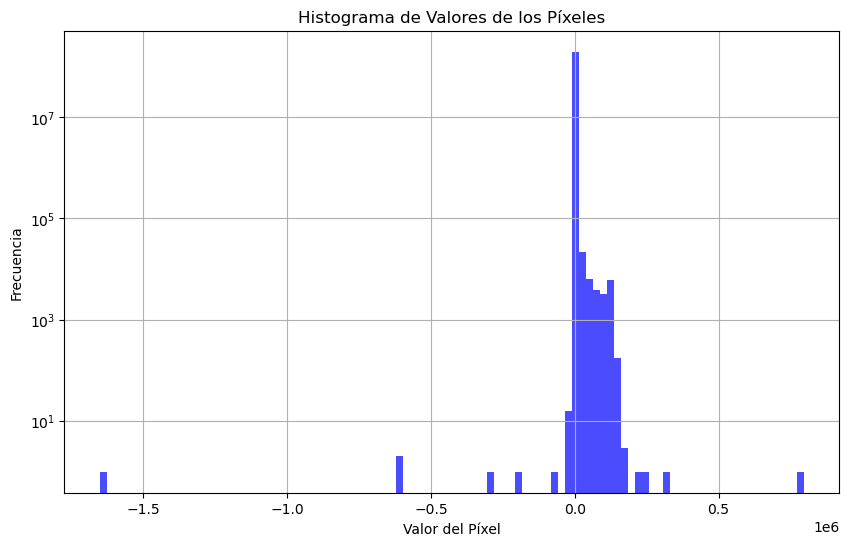

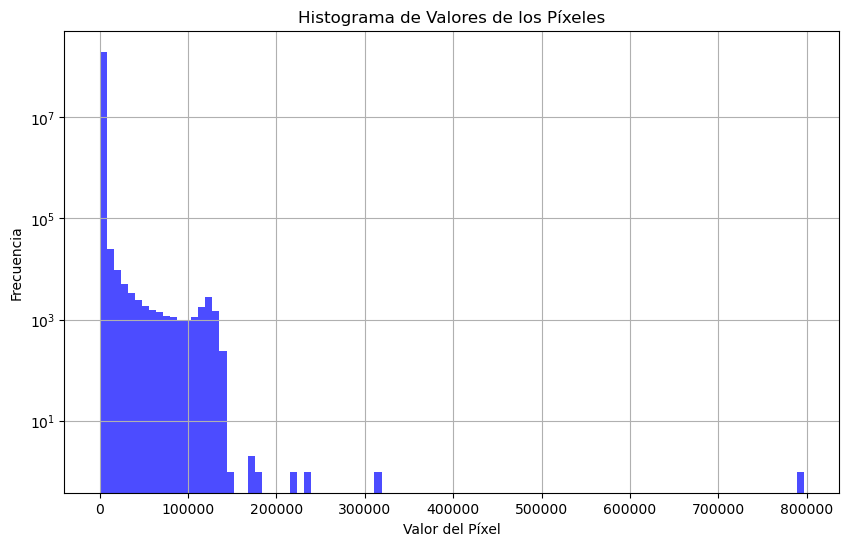

In [19]:
# Abrir el archivo FITS original
hdu_list = fits.open(path_background_nisp_h)
image_data = hdu_list[0].data
header = hdu_list[0].header  # Copiar la cabecera
hdu_list.close()

# Calcular la media y la desviación estándar de toda la imagen
mean_background = np.nanmedian(image_data)
std_background = np.nanstd(image_data)
min_val = np.nanmin(image_data)
print(min_val)
max_val = np.nanmax(image_data)
print(max_val)

print(mean_background)
print(std_background)

# Mostrar el histograma de los valores de los píxeles
plt.figure(figsize=(10, 6))
plt.hist(image_data.flatten(), bins=100, color='blue', alpha=0.7)
plt.title('Histograma de Valores de los Píxeles')
plt.xlabel('Valor del Píxel')
plt.ylabel('Frecuencia')
plt.yscale('log')  # Usar escala logarítmica para mejor visualización
plt.grid(True)
plt.show()

# Sustraer el ruido de fondo de la imagen completa
image_data_subtracted = image_data - pedestal_sky_nisp_h
# Ajustar los valores negativos a 0
image_data_subtracted = np.maximum(image_data_subtracted, 1e-10)
# Guardar la imagen con el ruido sustraído y la cabecera original
fits.writeto(path_background_nisp_h_without_pedestal, image_data_subtracted, header=header, overwrite=True)

# Mostrar el histograma de los valores de los píxeles
plt.figure(figsize=(10, 6))
plt.hist(image_data_subtracted.flatten(), bins=100, color='blue', alpha=0.7)
plt.title('Histograma de Valores de los Píxeles')
plt.xlabel('Valor del Píxel')
plt.ylabel('Frecuencia')
plt.yscale('log')  # Usar escala logarítmica para mejor visualización
plt.grid(True)
plt.show()

## NISP J

In [20]:
pedestal_sky_nisp_j = procesar_imagen(path_background_nisp_j)

Ejecutando: astnoisechisel "lsb_optimized_jan25/EUC_NIR_J_LSB_ObsID_2706.fits" -h0 --output=./EUC_NIR_J_LSB_ObsID_2706_noisechiseling_original.fits
NoiseChisel 0.22 started on Sun May 11 11:12:16 2025
  - Using 12 CPU threads.
  - Input: lsb_optimized_jan25/EUC_NIR_J_LSB_ObsID_2706.fits (hdu: 0)
  - Kernel: FWHM=2 pixel Gaussian.
  - Convolved with given kernel.                       8.585992 seconds
  - Starting to find initial detections.
  ---- 0.30 & 0.99 quantile thresholds applied.        5.313887 seconds
  ---- Eroded 2 times (4-connected).                   0.736659 seconds
  ---- Opened (depth: 1, 8-connected).                 0.570294 seconds
  - 325846 initial detections found.                   8.860916 seconds
  - Starting to find/remove false detections.
  ---- Initial (crude) Sky and its STD found.          4.482459 seconds
  ---- Pseudo-detection thresh (0.000 sigma) applied.  0.111186 seconds
  ---- Pseudo-det S/N: 7.645 (0.99 quant of 222928).   3.928967 seconds
  ---

-82008.76
343223.78
74.40009
1011.9698


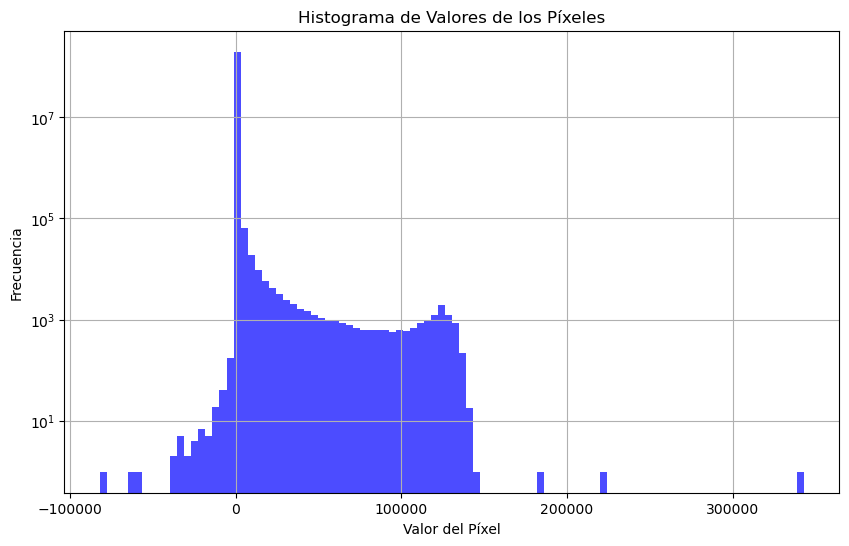

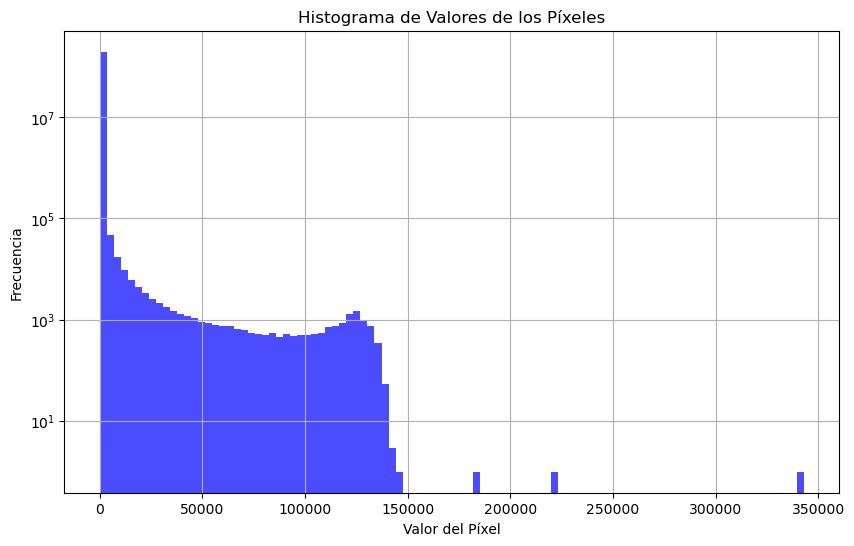

In [21]:
# Abrir el archivo FITS original
hdu_list = fits.open(path_background_nisp_j)
image_data = hdu_list[0].data
header = hdu_list[0].header  # Copiar la cabecera
hdu_list.close()

# Calcular la media y la desviación estándar de toda la imagen
mean_background = np.nanmedian(image_data)
std_background = np.nanstd(image_data)
min_val = np.nanmin(image_data)
print(min_val)
max_val = np.nanmax(image_data)
print(max_val)

print(mean_background)
print(std_background)

# Mostrar el histograma de los valores de los píxeles
plt.figure(figsize=(10, 6))
plt.hist(image_data.flatten(), bins=100, color='blue', alpha=0.7)
plt.title('Histograma de Valores de los Píxeles')
plt.xlabel('Valor del Píxel')
plt.ylabel('Frecuencia')
plt.yscale('log')  # Usar escala logarítmica para mejor visualización
plt.grid(True)
plt.show()

# Sustraer el ruido de fondo de la imagen completa
image_data_subtracted = image_data - pedestal_sky_nisp_j
# Ajustar los valores negativos a 0
image_data_subtracted = np.maximum(image_data_subtracted, 1e-10)
# Guardar la imagen con el ruido sustraído y la cabecera original
fits.writeto(path_background_nisp_j_without_pedestal, image_data_subtracted, header=header, overwrite=True)

# Mostrar el histograma de los valores de los píxeles
plt.figure(figsize=(10, 6))
plt.hist(image_data_subtracted.flatten(), bins=100, color='blue', alpha=0.7)
plt.title('Histograma de Valores de los Píxeles')
plt.xlabel('Valor del Píxel')
plt.ylabel('Frecuencia')
plt.yscale('log')  # Usar escala logarítmica para mejor visualización
plt.grid(True)
plt.show()

## NISP Y

In [22]:
pedestal_sky_nisp_y = procesar_imagen(path_background_nisp_y)

Ejecutando: astnoisechisel "lsb_optimized_jan25/EUC_NIR_Y_LSB_ObsID_2706.fits" -h0 --output=./EUC_NIR_Y_LSB_ObsID_2706_noisechiseling_original.fits
NoiseChisel 0.22 started on Sun May 11 11:13:41 2025
  - Using 12 CPU threads.
  - Input: lsb_optimized_jan25/EUC_NIR_Y_LSB_ObsID_2706.fits (hdu: 0)
  - Kernel: FWHM=2 pixel Gaussian.
  - Convolved with given kernel.                       8.531094 seconds
  - Starting to find initial detections.
  ---- 0.30 & 0.99 quantile thresholds applied.        4.578740 seconds
  ---- Eroded 2 times (4-connected).                   0.749919 seconds
  ---- Opened (depth: 1, 8-connected).                 0.582315 seconds
  - 357548 initial detections found.                   7.919202 seconds
  - Starting to find/remove false detections.
  ---- Initial (crude) Sky and its STD found.          3.631667 seconds
  ---- Pseudo-detection thresh (0.000 sigma) applied.  0.120614 seconds
  ---- Pseudo-det S/N: 7.353 (0.99 quant of 261591).   3.947807 seconds
  ---

-154401.66
147851.89
56.25965
885.8663


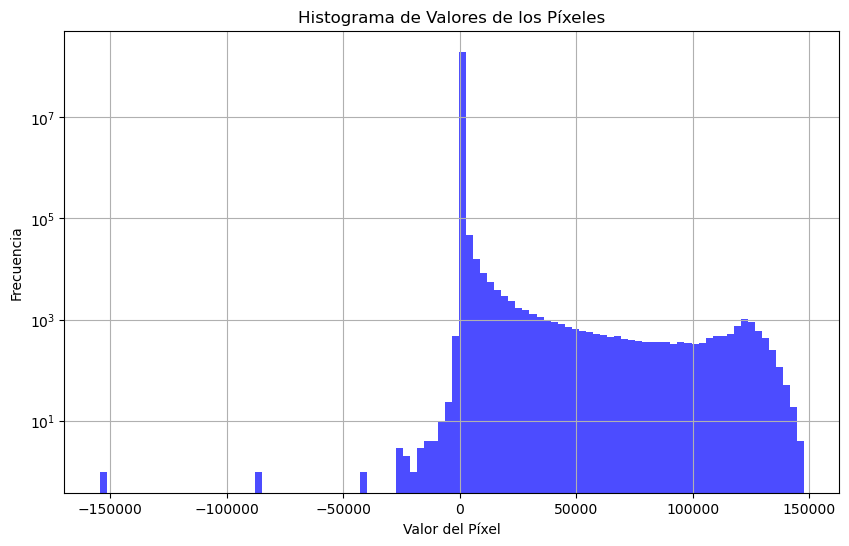

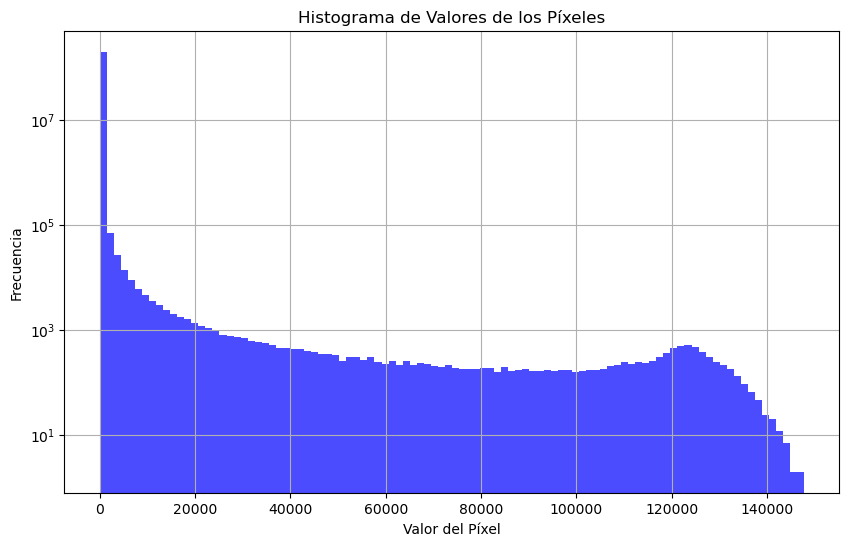

In [23]:
# Abrir el archivo FITS original
hdu_list = fits.open(path_background_nisp_y)
image_data = hdu_list[0].data
header = hdu_list[0].header  # Copiar la cabecera
hdu_list.close()

# Calcular la media y la desviación estándar de toda la imagen
mean_background = np.nanmedian(image_data)
std_background = np.nanstd(image_data)
min_val = np.nanmin(image_data)
print(min_val)
max_val = np.nanmax(image_data)
print(max_val)

print(mean_background)
print(std_background)

# Mostrar el histograma de los valores de los píxeles
plt.figure(figsize=(10, 6))
plt.hist(image_data.flatten(), bins=100, color='blue', alpha=0.7)
plt.title('Histograma de Valores de los Píxeles')
plt.xlabel('Valor del Píxel')
plt.ylabel('Frecuencia')
plt.yscale('log')  # Usar escala logarítmica para mejor visualización
plt.grid(True)
plt.show()

# Sustraer el ruido de fondo de la imagen completa
image_data_subtracted = image_data - pedestal_sky_nisp_y
# Ajustar los valores negativos a 0
image_data_subtracted = np.maximum(image_data_subtracted, 1e-10)
# Guardar la imagen con el ruido sustraído y la cabecera original
fits.writeto(path_background_nisp_y_without_pedestal, image_data_subtracted, header=header, overwrite=True)

# Mostrar el histograma de los valores de los píxeles
plt.figure(figsize=(10, 6))
plt.hist(image_data_subtracted.flatten(), bins=100, color='blue', alpha=0.7)
plt.title('Histograma de Valores de los Píxeles')
plt.xlabel('Valor del Píxel')
plt.ylabel('Frecuencia')
plt.yscale('log')  # Usar escala logarítmica para mejor visualización
plt.grid(True)
plt.show()